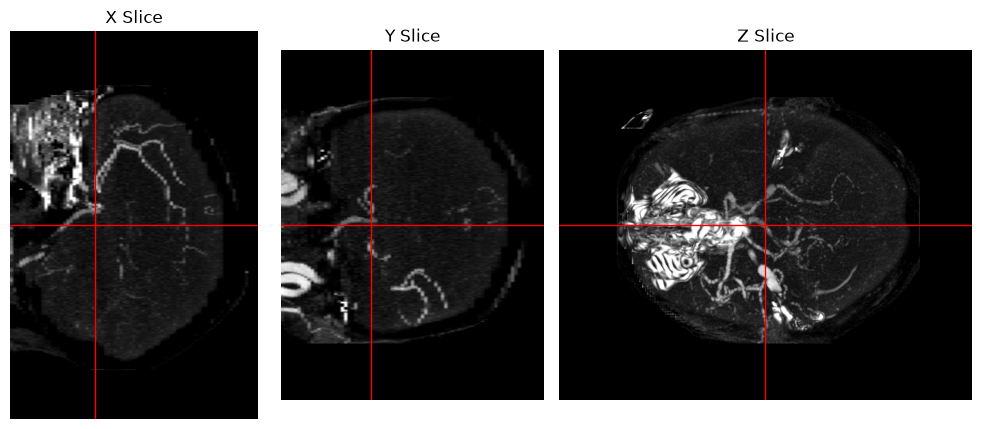

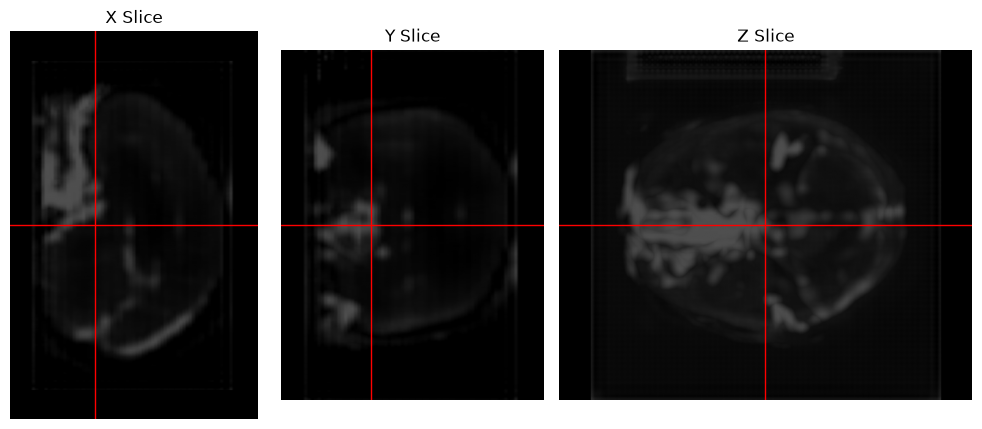

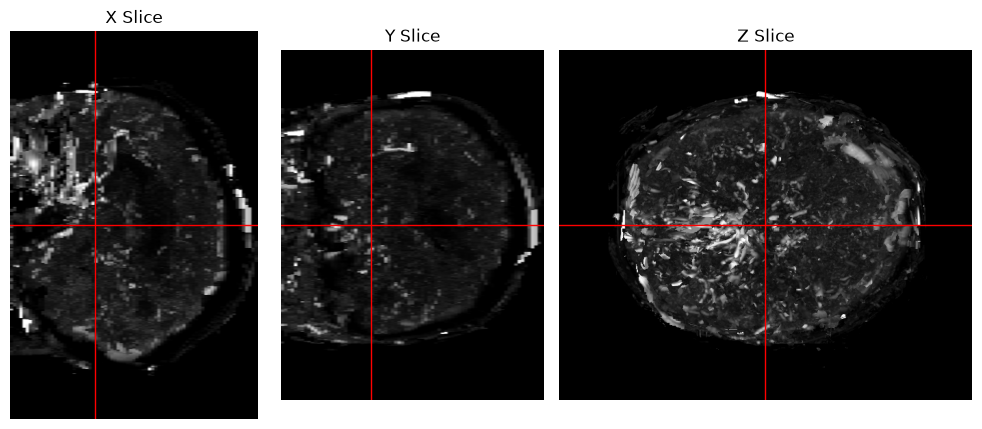

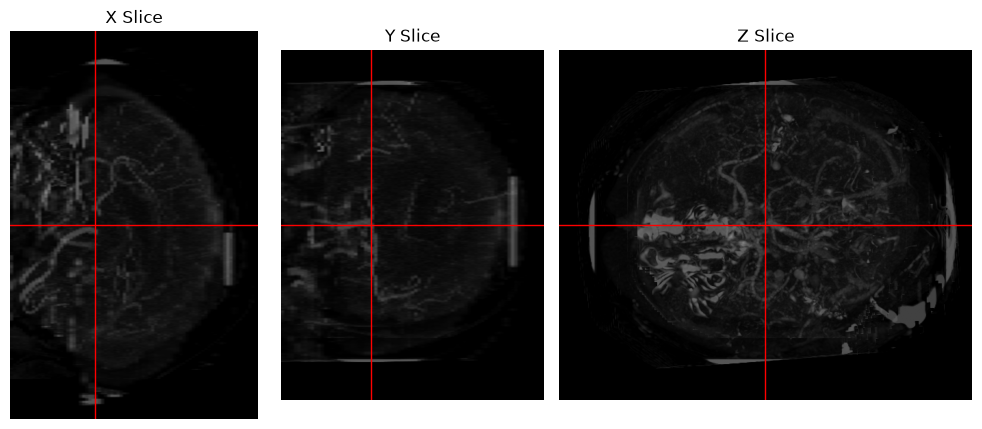

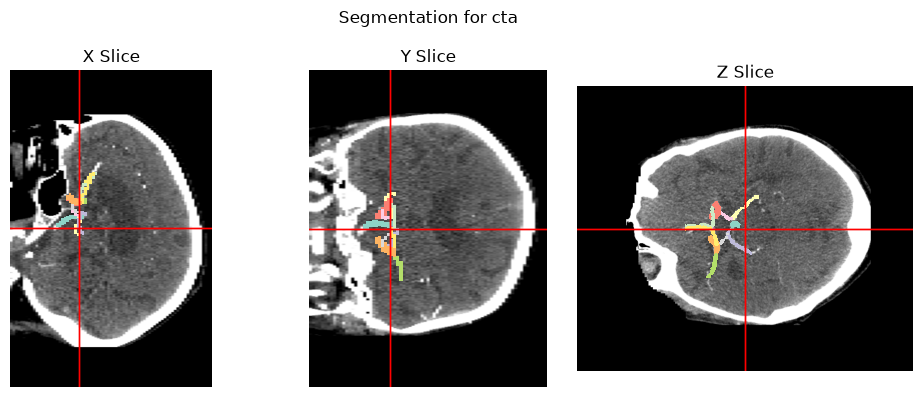

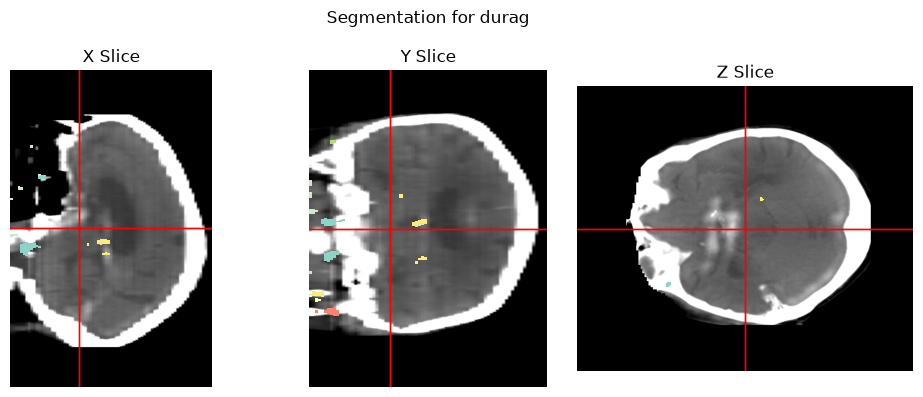

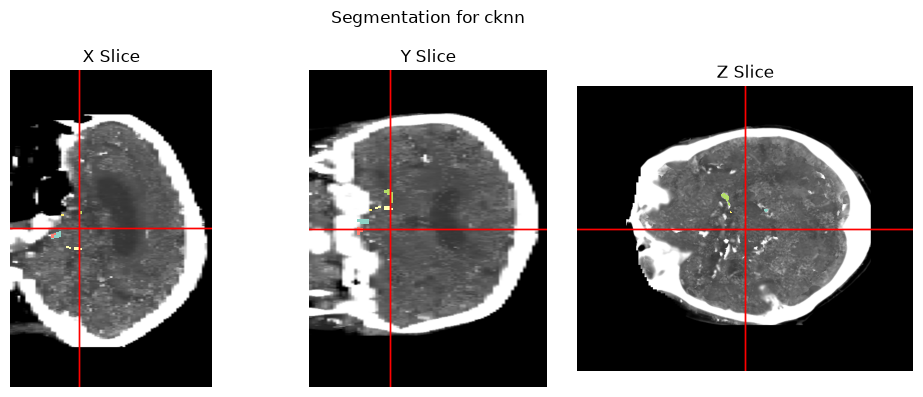

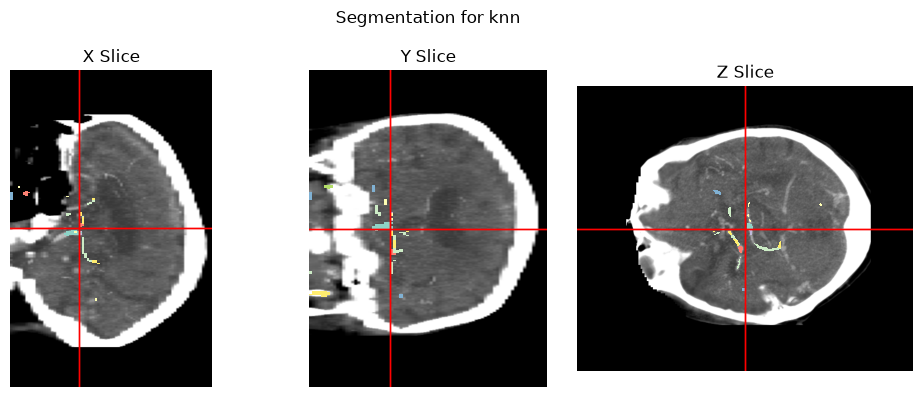

In [8]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from src.processing import CONSTANTS
from src.plots import plot_cta_and_segmentation, plot_from_path

pred_path = f"../{CONSTANTS.NORM_PRED_PATH}"
pred_path_norm = f"../{CONSTANTS.NORM_PRED_PATH}"
data_path_norm = f"../{CONSTANTS.NORM_DATA_PATH_VAL_OUT}"

case_channel = {"cta": ("0001","0001"),
                "durag": ("0001","0001"),
                #"ncct": ("0000","0000"), 
                "cknn": ("0001","0001"),
                "knn": ("0001","0001"),
                }


id_no = 10
id_no = str(id_no).zfill(4)

# First print the vessel structures
for case, channel in case_channel.items():
    
    if case == "cta":
        path = f"{data_path_norm}/case_{id_no}_{channel[0]}.nii.gz"
    else:
        path = f"{pred_path_norm}/images_norm_{case}/case_{id_no}_{channel[0]}.nii.gz"
    fig = plot_from_path(
        path=path,
        slices = (0.5, 0.5, 0.35),
        thicknesses = (20, 20, 20),
        cmap = "gray",
        vmin=-1,
        vmax=1
    )
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/vessel_{id_no}_{case}.png", dpi=300)

# Then print the secmentation results
for case, channel in case_channel.items():    
    input_case_path = f"{pred_path}/images_{case}/case_{id_no}_{channel[0]}.nii.gz"
    fig = plot_cta_and_segmentation(
        input_case_path=input_case_path,
        prediction_case_path=f"{pred_path}/segment_new_{case}/case_{id_no}_{channel[1]}.nii.gz",
        slices = (0.5, 0.5, 0.35),
        thickness = (1, 1, 1),
        figsize=(10, 4),
        cmap="gray",
        vmin=-50,
        vmax=200
    )
    plt.suptitle(f"Segmentation for {case}")
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/segmentation_{id_no}_{case}.png", dpi=300)